<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/Visualize_CNN_Filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
from keras.applications.vgg16 import VGG16
# load the model
model=VGG16()


In [29]:
# summarize the model
model.summary()


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

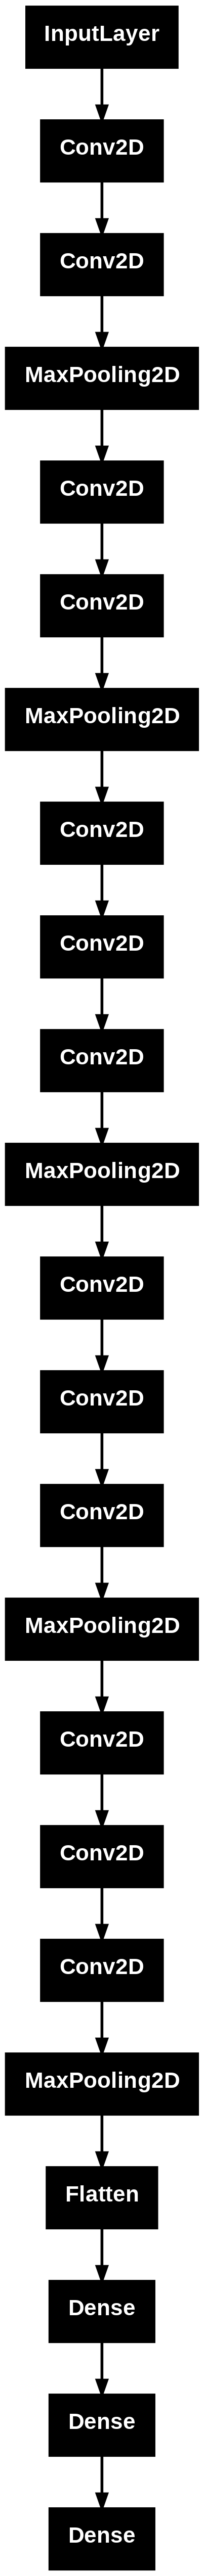

In [30]:
from keras.utils import plot_model
plot_model(model, to_file='vgg.png')

In [31]:
# pick the filters
for i in range(len(model.layers)):
    layer=model.layers[i]
    if 'conv' not in layer.name:
        continue
    #get filter weight
    filters,biases=layer.get_weights()
    print('layer Name',i,model.layers[i].name,filters.shape)


layer Name 1 block1_conv1 (3, 3, 3, 64)
layer Name 2 block1_conv2 (3, 3, 64, 64)
layer Name 4 block2_conv1 (3, 3, 64, 128)
layer Name 5 block2_conv2 (3, 3, 128, 128)
layer Name 7 block3_conv1 (3, 3, 128, 256)
layer Name 8 block3_conv2 (3, 3, 256, 256)
layer Name 9 block3_conv3 (3, 3, 256, 256)
layer Name 11 block4_conv1 (3, 3, 256, 512)
layer Name 12 block4_conv2 (3, 3, 512, 512)
layer Name 13 block4_conv3 (3, 3, 512, 512)
layer Name 15 block5_conv1 (3, 3, 512, 512)
layer Name 16 block5_conv2 (3, 3, 512, 512)
layer Name 17 block5_conv3 (3, 3, 512, 512)


In [32]:
# retrive the weight from second hidden layer
filters,biases=model.layers[1].get_weights()


In [33]:
# normalize the filter
f_min,fmax=filters.min(),filters.max()
filters=(filters-f_min)/(fmax-f_min)

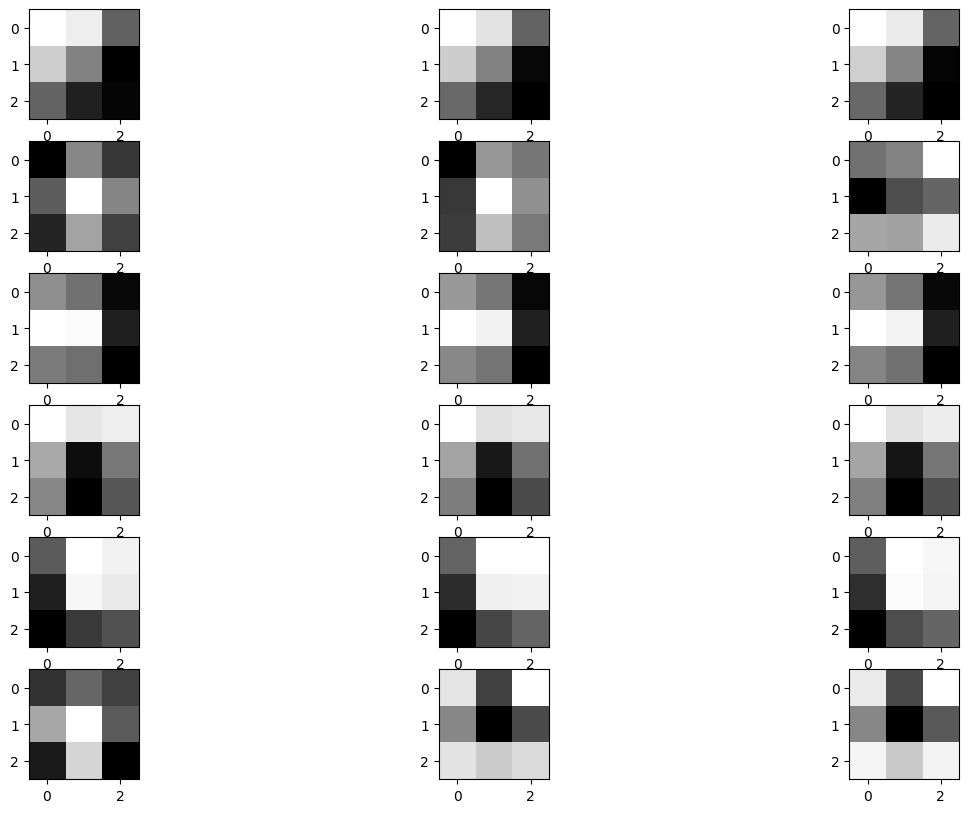

In [34]:
import numpy as np
from matplotlib import pyplot
n_filters=6
ix=1
fig=pyplot.figure(figsize=(15,10))
for i in range (n_filters):
    #get the filter
    f=filters[:,:,:,i]
    #plot the filter
    for j in range(3):
      #  subplot for 6 filter and 3 channel
      pyplot.subplot(n_filters,3,ix)
      pyplot.imshow(f[:,:,j],cmap='gray')
      ix+=1
# plot the filter
pyplot.show()



In [35]:
from keras.models import Model
model=Model(inputs=model.inputs,outputs=model.layers[1].output)


In [36]:
from keras.applications.vgg16 import preprocess_input
from keras.preprocessing.image import load_img
from numpy import expand_dims
from keras.preprocessing.image import img_to_array
image=load_img('/content/subash.jpeg',target_size=(224,224))

# convert imge ti an array
image=img_to_array(image)

# expand the dimesion
image=expand_dims(image,axis=0)

# prepare the image
image=preprocess_input(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


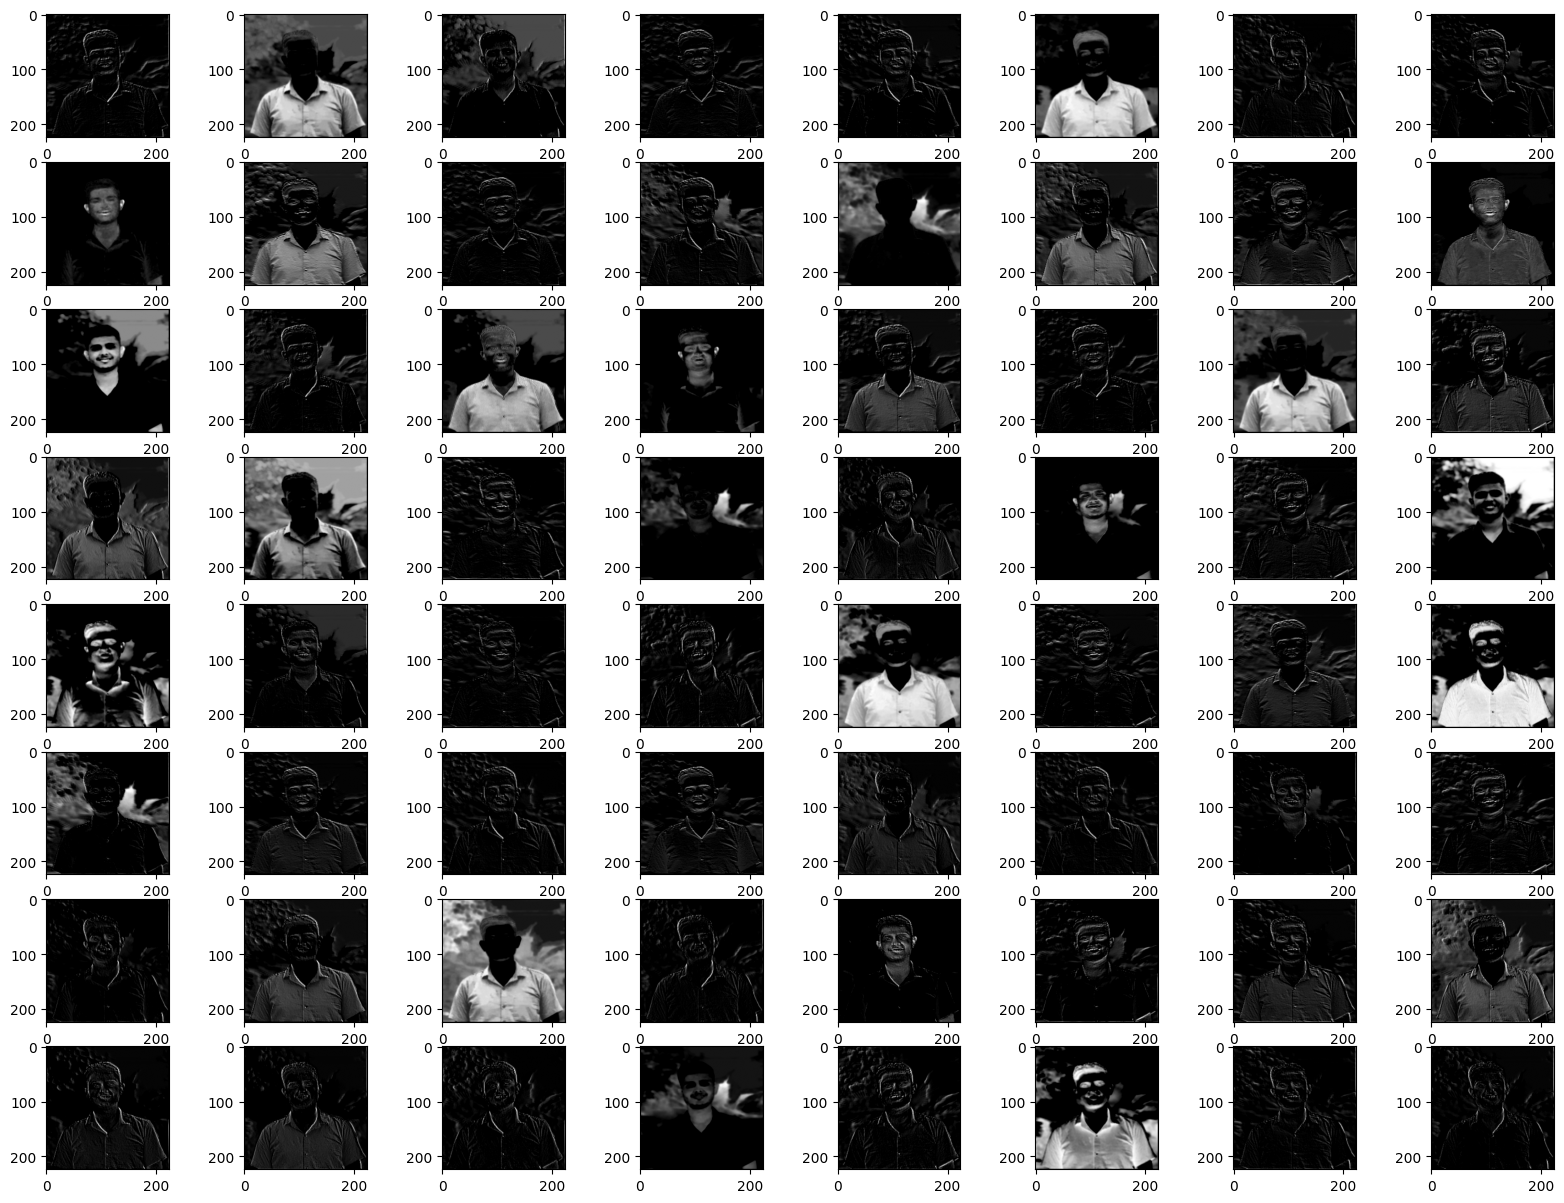

In [37]:
# caculatiig feature map
features=model.predict(image)

fig=pyplot.figure(figsize=(20,15))

for i in range(1,features.shape[3]+1):
  pyplot.subplot(8,8,i)
  pyplot.imshow(features[0,:,:,i-1],cmap='gray')
pyplot.show()


In [38]:
model2=VGG16()

In [40]:
layer_index=[2,5,9,13,17]
outputs=[model2.layers[i].output for i in layer_index]
model3=Model(inputs=model2.inputs,outputs=outputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


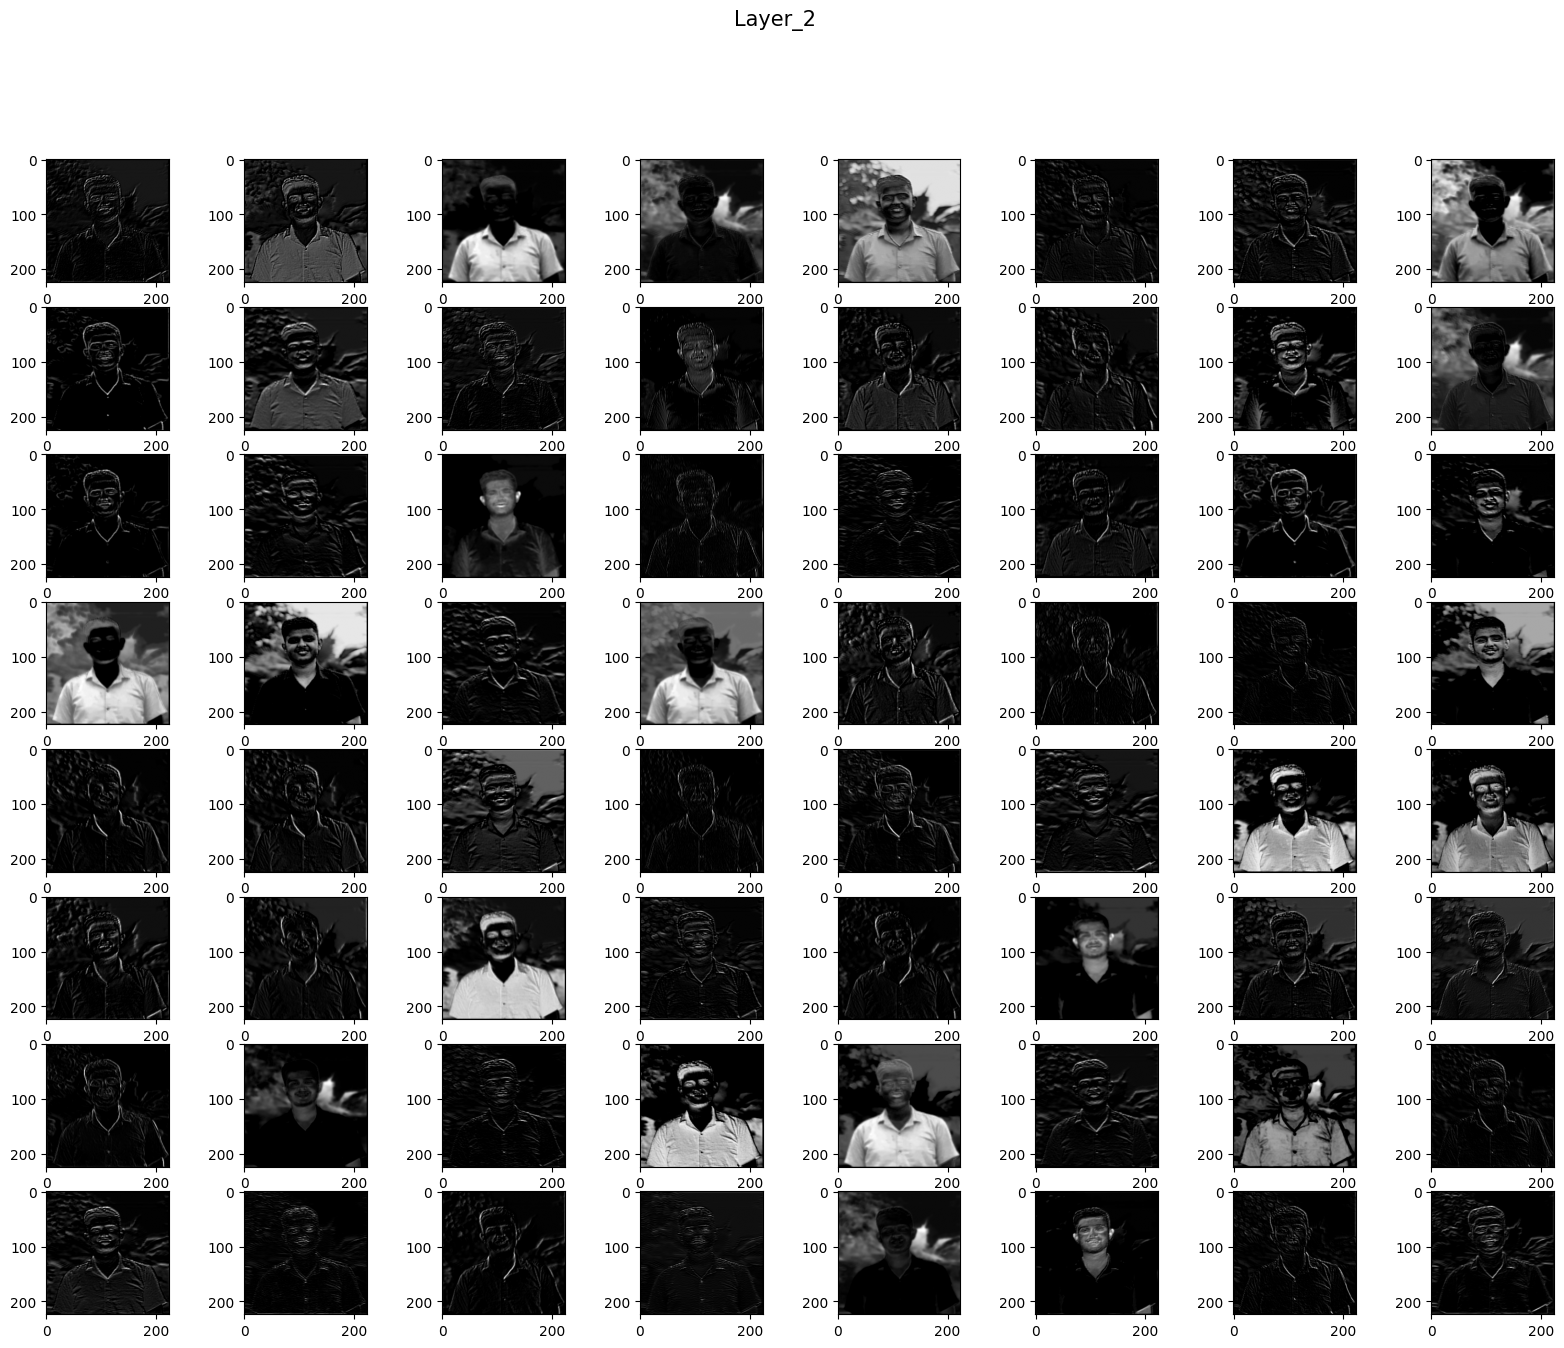

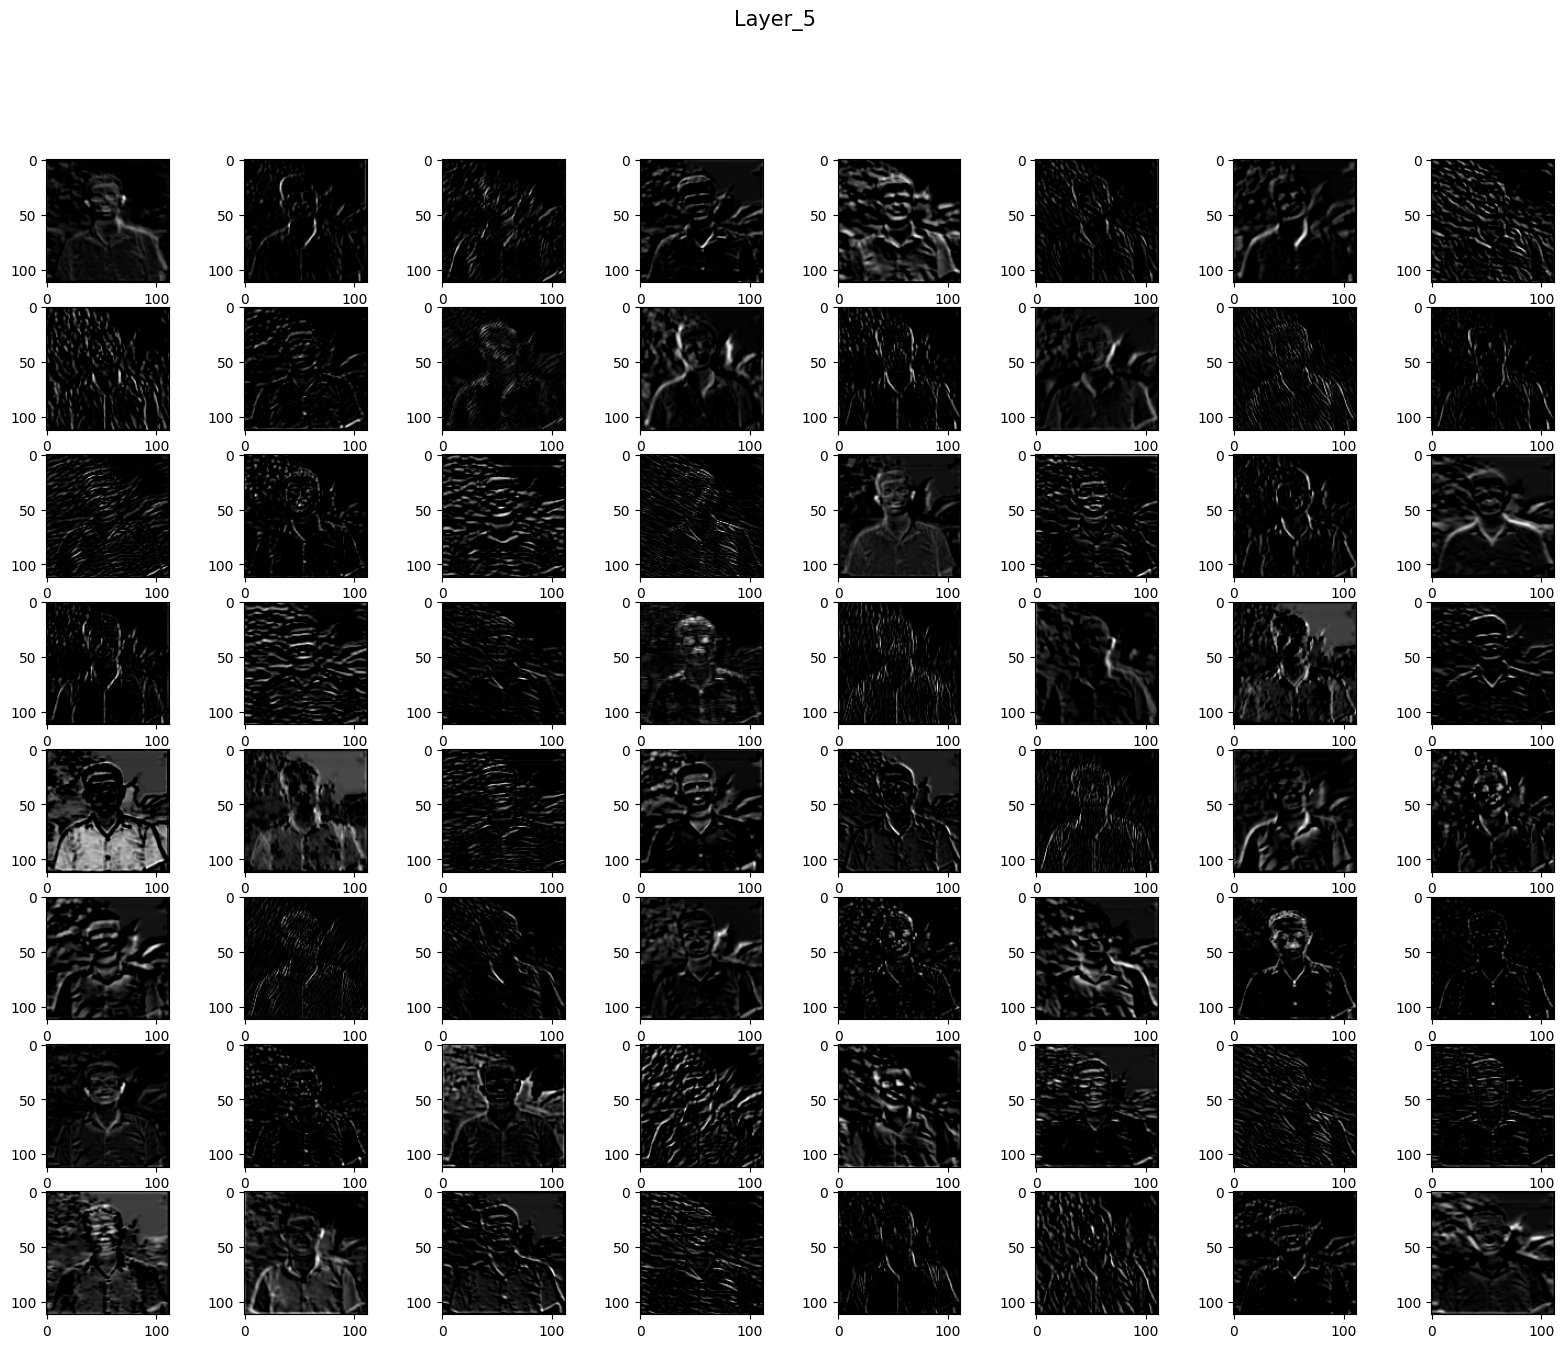

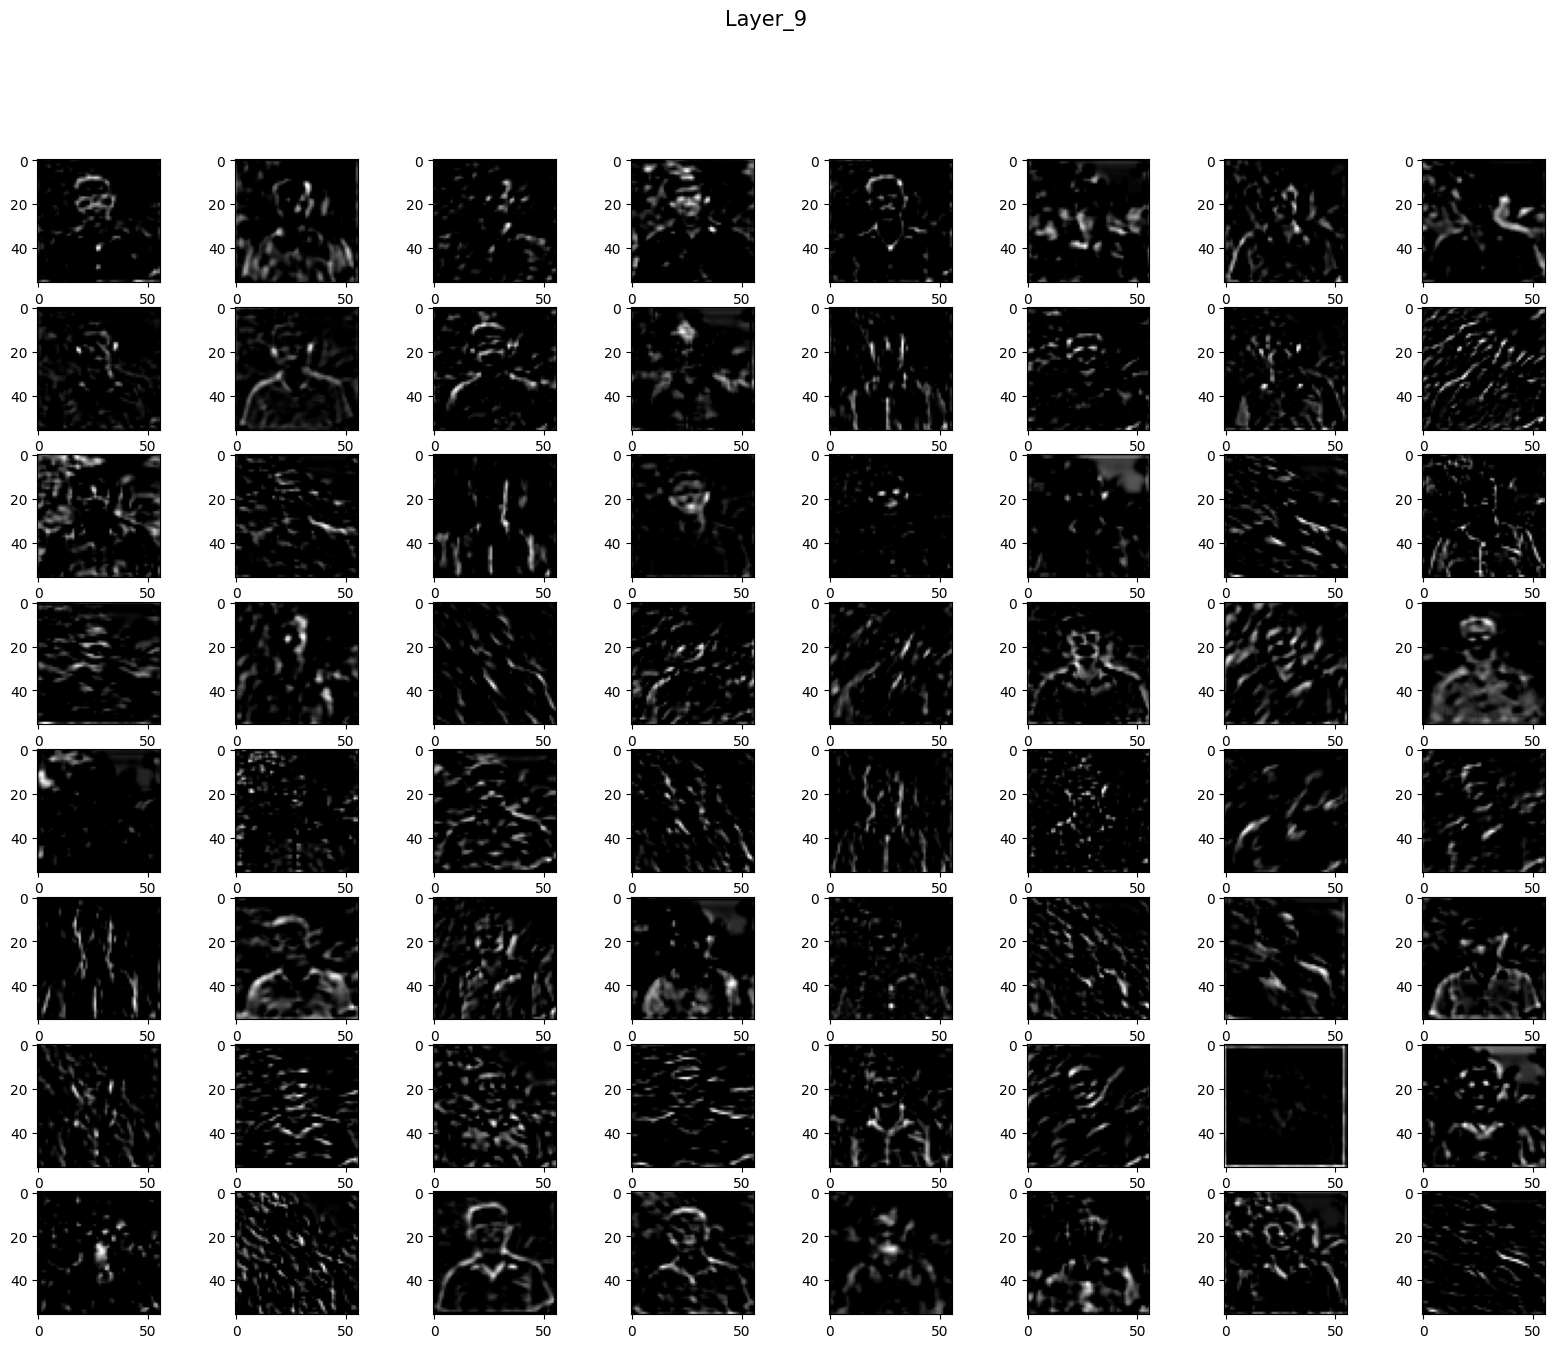

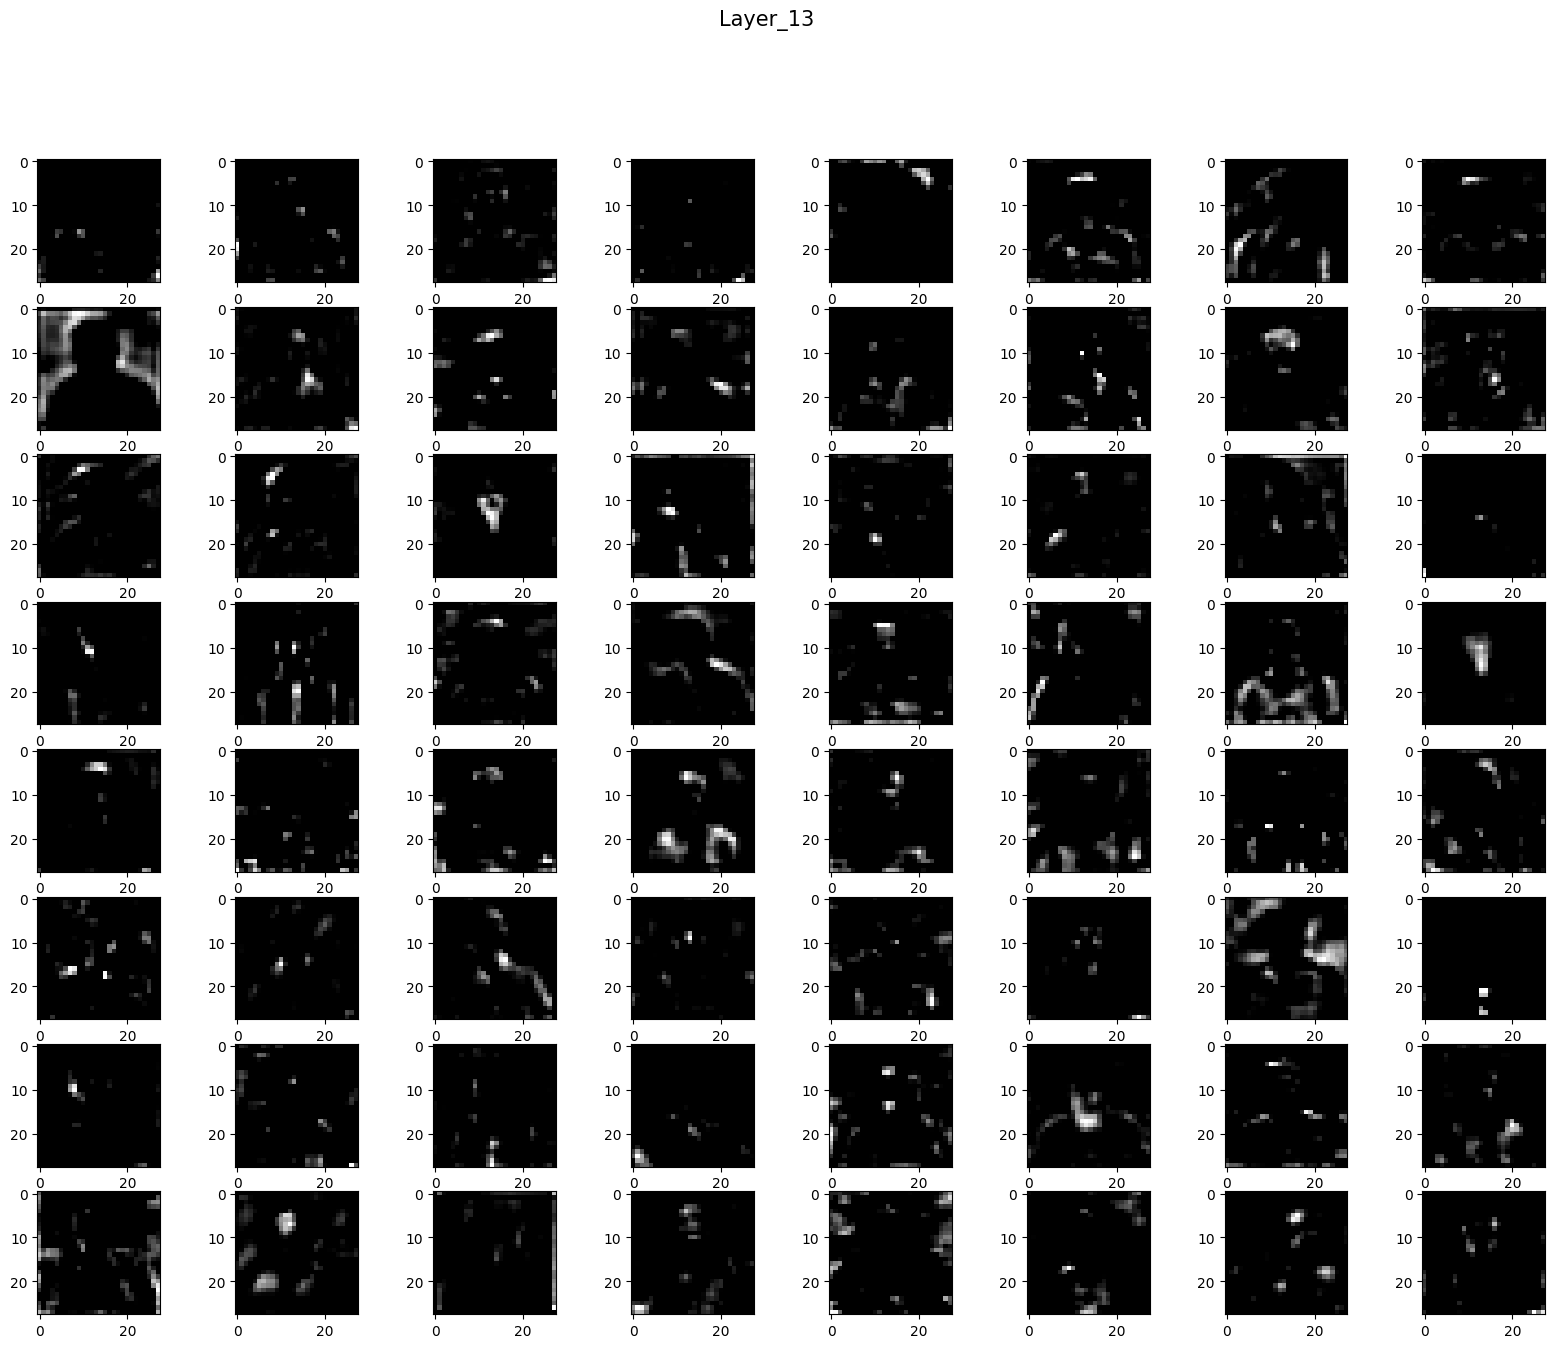

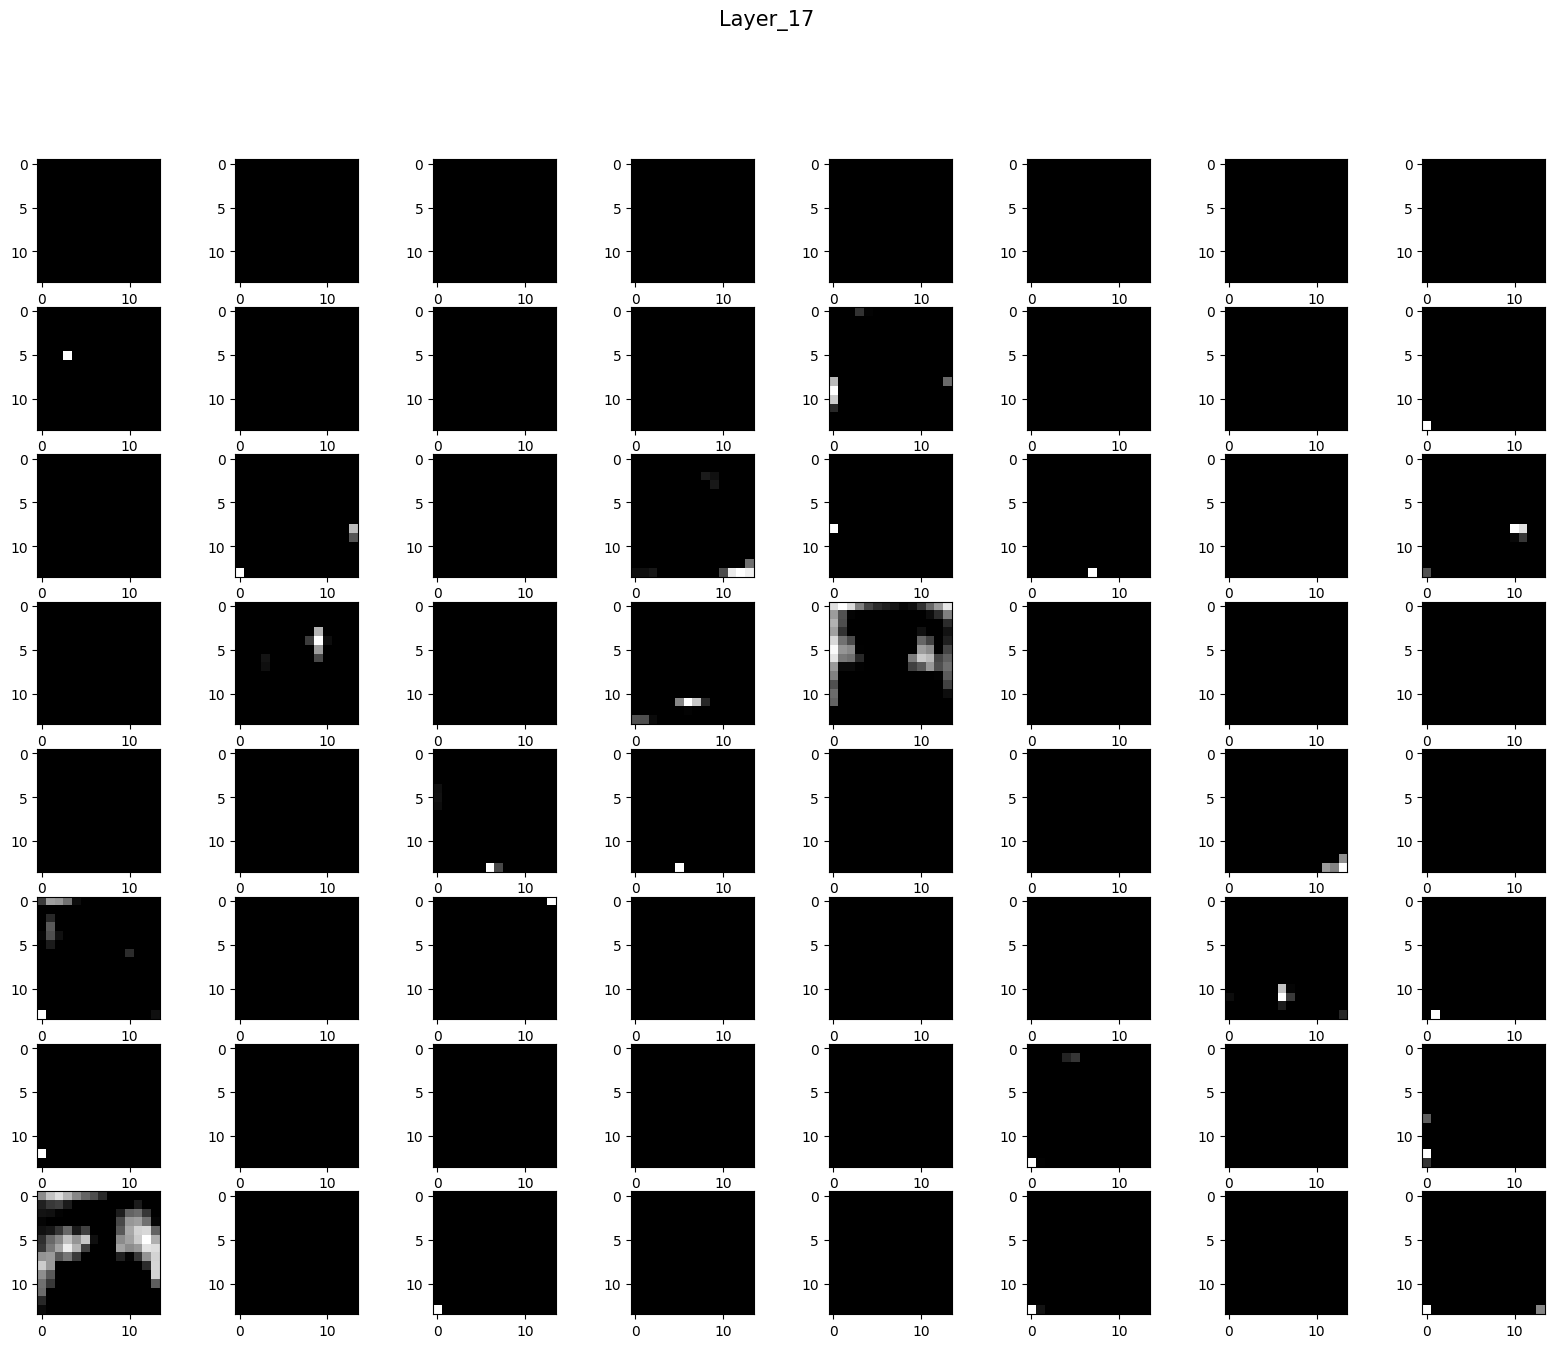

In [44]:
feature_map=model3.predict(image)

for i,feature_map in zip(layer_index,feature_map):
  fig=pyplot.figure(figsize=(20,15))
  fig.suptitle("Layer_{}".format(i),fontsize=15)
  for i in range(1,features.shape[3]+1):
    pyplot.subplot(8,8,i)
    pyplot.imshow(feature_map[0,:,:,i-1],cmap='gray')
  pyplot.show()